# Backtest Validation

## Overview

This notebook demonstrates the public functions in `backtest_validation` using a compact synthetic event table.
- It generates combinatorial purged cross-validation splits.
- It arranges the splits into combinatorial backtest paths.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from src.model_backtesting.backtest_validation import (
    combinatorial_purged_cross_validation,
    get_combinatorial_backtest_paths,
)

## Combinatorial Purged Cross-Validation

This cell defines the example inputs for CPCV.
- `samples_info_sets` is indexed by event start time and valued by event end time.
- `num_groups` controls how many contiguous observation groups are formed.
- `num_test_groups` controls how many groups are used as the test set in each split.
- The event horizon plot shows how overlapping labels create observations that must be purged and embargoed.

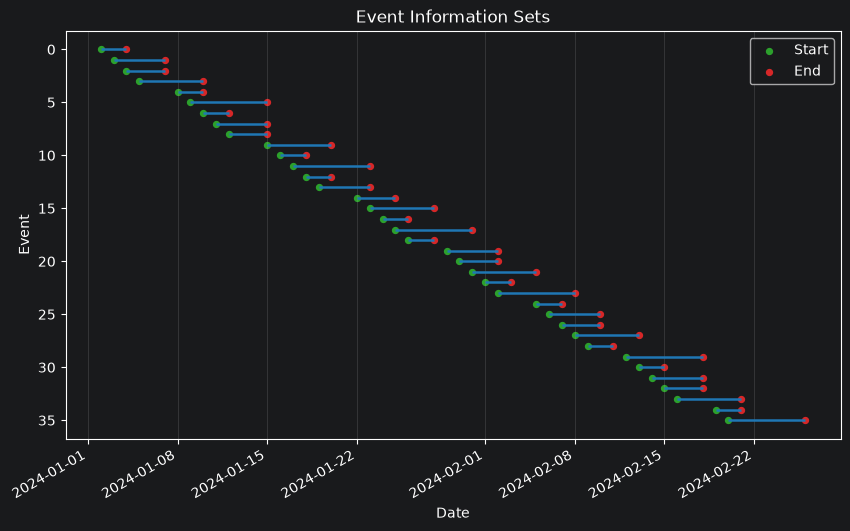

In [3]:
dates = pd.bdate_range("2024-01-02", periods=36)
holding_periods = np.tile([2, 4, 3, 5, 2, 6], 6)

samples_info_sets = pd.Series(
    dates + pd.to_timedelta(holding_periods, unit="D"),
    index=dates,
    name="t1",
)

num_groups = 6
num_test_groups = 2
pct_embargo = 0.03

fig, ax = plt.subplots(figsize=(10, 6))
event_positions = np.arange(samples_info_sets.shape[0])

ax.hlines(
    y=event_positions,
    xmin=samples_info_sets.index,
    xmax=samples_info_sets.values,
    color="tab:blue",
    linewidth=1.8,
)
ax.scatter(samples_info_sets.index, event_positions, color="tab:green", s=18, label="Start")
ax.scatter(samples_info_sets.values, event_positions, color="tab:red", s=18, label="End")

ax.set_title("Event Information Sets")
ax.set_xlabel("Date")
ax.set_ylabel("Event")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.show()

This cell formats the CPCV split table.
- Rows `G1` through `G6` are contiguous observation groups.
- Columns `S1` through `S15` are the `C(6, 2) = 15` train/test splits.
- `x` marks the groups included in each test set.

In [4]:
splits = combinatorial_purged_cross_validation(
    samples_info_sets=samples_info_sets,
    num_groups=num_groups,
    num_test_groups=num_test_groups,
    pct_embargo=pct_embargo,
)

split_columns = [f"S{split_num + 1}" for split_num in splits["split_num"]]
figure_12_1 = pd.DataFrame(
    "",
    index=[f"G{group + 1}" for group in range(num_groups)],
    columns=split_columns,
)

for _, split in splits.iterrows():
    split_column = f"S{split['split_num'] + 1}"
    for group in split["test_groups"]:
        figure_12_1.loc[f"G{group + 1}", split_column] = "x"

figure_12_1["Paths"] = (figure_12_1 == "x").sum(axis=1)

display(figure_12_1)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15,Paths
G1,x,x,x,x,x,,,,,,,,,,,5
G2,x,,,,,x,x,x,x,,,,,,,5
G3,,x,,,,x,,,,x,x,x,,,,5
G4,,,x,,,,x,,,x,,,x,x,,5
G5,,,,x,,,,x,,,x,,x,,x,5
G6,,,,,x,,,,x,,,x,,x,x,5


This cell formats the CPCV path assignment table.
- Rows `G1` through `G6` are contiguous observation groups.
- Columns `S1` through `S15` are the same split combinations used in the split table.
- `Paths` shows that each group appears in `𝜑[N,k] = 5` test sets.

In [5]:
paths = get_combinatorial_backtest_paths(
    splits=splits,
    num_groups=num_groups,
)

figure_12_2 = pd.DataFrame(
    "",
    index=[f"G{group + 1}" for group in range(num_groups)],
    columns=split_columns,
)

for path_num, split_nums in enumerate(paths.T.to_numpy(), start=1):
    for group, split_num in enumerate(split_nums):
        split_column = f"S{split_num + 1}"
        figure_12_2.loc[f"G{group + 1}", split_column] = str(path_num)

figure_12_2["Paths"] = (figure_12_2 != "").sum(axis=1)

display(figure_12_2)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15,Paths
G1,1,2,3,4,5,,,,,,,,,,,5
G2,1,,,,,2,3,4,5,,,,,,,5
G3,,1,,,,2,,,,3,4,5,,,,5
G4,,,1,,,,2,,,3,,,4,5,,5
G5,,,,1,,,,2,,,3,,4,,5,5
G6,,,,,1,,,,2,,,3,,4,5,5
